# Notebook 03 — Extraction des Polluants & Calcul de l'AQI US EPA

## Objectif

Ce notebook produit la **base consolidée de qualité de l'air 2020-2025** pour 40 villes camerounaises,
avec un AQI calculé manuellement selon la norme US EPA (EPA-454/B-24-002).

## Sources et séparation des périodes

| Source | Période | Méthode |
|--------|---------|--------|
| **CAMS EAC4** (Copernicus ADS) | 2020-01-01 → 2022-08-07 | 8 obs/jour (3-horaires) |
| **Open-Meteo** Air Quality API | 2022-08-08 → 2025-12-31 | Données horaires (24 obs/jour) |

## Pipeline

1. **Section 1** — Imports, constantes, test de connectivité
2. **Section 2** — Extraction Open-Meteo, agrégation EPA, calcul AQI manuel
3. **Section 3** — Extraction CAMS EAC4, agrégation adaptée, calcul AQI
4. **Section 4** — Fusion et export final (`air_quality_aqi_2020_2025`)
5. **Section 5** — 5 visualisations diagnostiques
6. **Section 6** — Rapport de synthèse textuel


## SECTION 1 — Imports et Configuration


In [1]:
## ── [SECTION 1] Imports, constantes et configuration globale ──────────────────
# Bibliothèques standard et scientifiques
import requests
import pandas as pd
import numpy as np
import logging
import warnings
import zipfile
import time as time_module
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from datetime import datetime, date

# Tentative d'import des bibliothèques CAMS (optionnelles)
try:
    import xarray as xr
    import cdsapi
    import openpyxl
    CAMS_AVAILABLE = True
except ImportError:
    CAMS_AVAILABLE = False

warnings.filterwarnings('ignore')

# ── Configuration du logger (format HH:MM:SS [LEVEL] message) ─────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S',
    force=True,  # Réinitialise les handlers existants
)
logger = logging.getLogger(__name__)

# ── Style graphique ────────────────────────────────────────────────────────────
sns.set_style('whitegrid')
sns.set_palette('colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

# ── Constantes globales ────────────────────────────────────────────────────────
DATE_START_CAMS = '2020-01-01'
DATE_END_CAMS   = '2022-08-07'   # CAMS jusqu'au 7 août 2022 inclus
DATE_START_OM   = '2022-08-08'   # Open-Meteo à partir du 8 août 2022
DATE_END_OM     = '2025-12-31'

OPENMETEO_URL = 'https://air-quality-api.open-meteo.com/v1/air-quality'
ADS_DATASET   = 'cams-global-reanalysis-eac4'

# Bounding box Cameroun [Nord, Ouest, Sud, Est] — format attendu par l'API ADS
CAMEROON_BBOX = [13.5, 8.0, 1.5, 16.5]

# Dossier de sortie
OUTPUT_DIR = Path('./data')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'cams_eac4').mkdir(parents=True, exist_ok=True)

MAX_RETRIES = 3
SLEEP_BASE  = 1.0  # secondes entre tentatives (multiplié par le numéro de tentative)

# ── Dictionnaire des 40 villes camerounaises ───────────────────────────────────
# Source : coordonnées géographiques officielles, une ville par chef-lieu de région
VILLES = {
    'Bafia':         {'lat': 4.7500,  'lon': 11.2333, 'region': 'Centre'},
    'Akonolinga':    {'lat': 3.7667,  'lon': 12.2500, 'region': 'Centre'},
    'Yaounde':       {'lat': 3.8667,  'lon': 11.5167, 'region': 'Centre'},
    'Mbalmayo':      {'lat': 3.5167,  'lon': 11.5000, 'region': 'Centre'},
    'Tibati':        {'lat': 6.4667,  'lon': 12.6333, 'region': 'Adamaoua'},
    'Tignere':       {'lat': 7.3667,  'lon': 12.6500, 'region': 'Adamaoua'},
    'Ngaoundere':    {'lat': 7.3167,  'lon': 13.5833, 'region': 'Adamaoua'},
    'Meiganga':      {'lat': 6.5167,  'lon': 14.2833, 'region': 'Adamaoua'},
    'Bertoua':       {'lat': 4.5833,  'lon': 13.6833, 'region': 'Est'},
    'Abong-Mbang':   {'lat': 3.9833,  'lon': 13.1667, 'region': 'Est'},
    'Batouri':       {'lat': 4.4333,  'lon': 14.3667, 'region': 'Est'},
    'Yokadouma':     {'lat': 3.5167,  'lon': 15.0500, 'region': 'Est'},
    'Maroua':        {'lat': 10.5908, 'lon': 14.3159, 'region': 'Extreme-Nord'},
    'Kousseri':      {'lat': 12.0767, 'lon': 15.0314, 'region': 'Extreme-Nord'},
    'Mokolo':        {'lat': 10.7333, 'lon': 13.8000, 'region': 'Extreme-Nord'},
    'Yagoua':        {'lat': 10.3500, 'lon': 15.2333, 'region': 'Extreme-Nord'},
    'Edea':          {'lat': 3.8000,  'lon': 10.1333, 'region': 'Littoral'},
    'Nkongsamba':    {'lat': 4.9500,  'lon': 9.9333,  'region': 'Littoral'},
    'Loum':          {'lat': 4.7167,  'lon': 9.7333,  'region': 'Littoral'},
    'Douala':        {'lat': 4.0500,  'lon': 9.7000,  'region': 'Littoral'},
    'Garoua':        {'lat': 9.3017,  'lon': 13.3921, 'region': 'Nord'},
    'Guider':        {'lat': 9.9333,  'lon': 13.9500, 'region': 'Nord'},
    'Poli':          {'lat': 8.4833,  'lon': 13.2333, 'region': 'Nord'},
    'Touboro':       {'lat': 7.7667,  'lon': 15.3667, 'region': 'Nord'},
    'Bamenda':       {'lat': 5.9597,  'lon': 10.1458, 'region': 'Nord-Ouest'},
    'Kumbo':         {'lat': 6.2000,  'lon': 10.6833, 'region': 'Nord-Ouest'},
    'Wum':           {'lat': 6.3833,  'lon': 10.0667, 'region': 'Nord-Ouest'},
    'Mbengwi':       {'lat': 6.0167,  'lon': 10.0000, 'region': 'Nord-Ouest'},
    'Bafoussam':     {'lat': 5.4737,  'lon': 10.4179, 'region': 'Ouest'},
    'Dschang':       {'lat': 5.4500,  'lon': 10.0500, 'region': 'Ouest'},
    'Foumban':       {'lat': 5.7167,  'lon': 10.9000, 'region': 'Ouest'},
    'Mbouda':        {'lat': 5.6167,  'lon': 10.2500, 'region': 'Ouest'},
    'Ebolowa':       {'lat': 2.9000,  'lon': 11.1500, 'region': 'Sud'},
    'Kribi':         {'lat': 2.9500,  'lon': 9.9167,  'region': 'Sud'},
    'Sangmelima':    {'lat': 2.9333,  'lon': 11.9833, 'region': 'Sud'},
    'Ambam':         {'lat': 2.3833,  'lon': 11.2833, 'region': 'Sud'},
    'Buea':          {'lat': 4.1597,  'lon': 9.2417,  'region': 'Sud-Ouest'},
    'Limbe':         {'lat': 4.0167,  'lon': 9.2000,  'region': 'Sud-Ouest'},
    'Kumba':         {'lat': 4.6333,  'lon': 9.4500,  'region': 'Sud-Ouest'},
    'Mamfe':         {'lat': 5.7667,  'lon': 9.2833,  'region': 'Sud-Ouest'},
}

logger.info(f'[OK] {len(VILLES)} villes chargées.')
logger.info(f'[OK] CAMS disponible : {CAMS_AVAILABLE}')


17:38:58 [INFO] [OK] 40 villes chargées.
17:38:58 [INFO] [OK] CAMS disponible : True


In [2]:
## ── [SECTION 1 suite] Test de connectivité Open-Meteo ───────────────────────
# Vérifier que l'API Open-Meteo répond avant de lancer l'extraction complète
def test_openmeteo_connectivity():
    """Requête test sur Yaoundé, 3 jours — vérifie que l'API répond correctement."""
    params = {
        'latitude': 3.8667, 'longitude': 11.5167,
        'hourly': 'pm2_5,pm10',
        'start_date': '2023-01-01', 'end_date': '2023-01-03',
        'timezone': 'auto',
    }
    try:
        r = requests.get(OPENMETEO_URL, params=params, timeout=15)
        r.raise_for_status()
        data = r.json()
        n = len(data.get('hourly', {}).get('time', []))
        logger.info(f'[OK] Connectivité Open-Meteo confirmée — {n} heures test reçues.')
        return True
    except Exception as e:
        logger.warning(f'[ATTENTION] Open-Meteo inaccessible : {e}')
        return False

OM_ONLINE = test_openmeteo_connectivity()

# Vérification de la disponibilité de cdsapi pour CAMS
if CAMS_AVAILABLE:
    logger.info('[OK] cdsapi + xarray disponibles — CAMS EAC4 activé.')
else:
    logger.warning('[ATTENTION] cdsapi ou xarray non installés — Section CAMS désactivée.')


17:39:00 [INFO] [OK] Connectivité Open-Meteo confirmée — 72 heures test reçues.
17:39:00 [INFO] [OK] cdsapi + xarray disponibles — CAMS EAC4 activé.


## SECTION 2 — Extraction Open-Meteo (8 août 2022 → 31 décembre 2025)

Stratégie : extraction des données **horaires brutes**, puis agrégation journalière
selon les règles EPA (fenêtre glissante 8h pour O3 et CO, max 24h pour NO2 et SO2,
moyenne 24h pour PM2.5 et PM10).


In [3]:
## ── [SECTION 2 — Partie A] Fonctions d'extraction Open-Meteo ────────────────

# Seules les 6 concentrations horaires sont extraites (µg/m³)
# Les AQI précalculés Open-Meteo sont retirés pour alléger les requêtes
# et réduire les risques de timeout.
OM_HOURLY_VARS = [
    'pm2_5', 'pm10', 'nitrogen_dioxide', 'ozone',
    'carbon_monoxide', 'sulphur_dioxide',
]

# Correspondance noms API Open-Meteo → noms courts internes
OM_RENAME = {
    'nitrogen_dioxide': 'no2',
    'ozone':            'o3',
    'carbon_monoxide':  'co',
    'sulphur_dioxide':  'so2',
}


def fetch_openmeteo_hourly(city, lat, lon, start, end):
    """
    Récupère les données horaires Open-Meteo pour une ville sur une période donnée.
    Retente MAX_RETRIES fois avec backoff linéaire en cas d'erreur réseau.
    """
    params = {
        'latitude':   lat,
        'longitude':  lon,
        'hourly':     ','.join(OM_HOURLY_VARS),
        'start_date': start,
        'end_date':   end,
        'timezone':   'auto',
    }
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            r = requests.get(OPENMETEO_URL, params=params, timeout=60)
            r.raise_for_status()
            data = r.json().get('hourly', {})
            if not data:
                return pd.DataFrame()
            df = pd.DataFrame(data)
            df['time'] = pd.to_datetime(df['time'])
            df['city'] = city
            df.rename(columns=OM_RENAME, inplace=True)
            return df
        except Exception as e:
            if attempt < MAX_RETRIES:
                time_module.sleep(SLEEP_BASE * attempt)
            else:
                logger.error(f'[ERREUR] {city} {start}/{end} : {e}')
                return pd.DataFrame()


def get_monthly_segments(start_str, end_str):
    """
    Découpe [start_str, end_str] en segments MENSUELS pour éviter les timeouts.
    Retourne une liste de tuples (debut, fin) au format 'YYYY-MM-DD'.
    """
    segments = []
    current = pd.Timestamp(start_str)
    end     = pd.Timestamp(end_str)
    while current <= end:
        month_end = (current + pd.offsets.MonthEnd(0))
        seg_end   = min(month_end, end)
        segments.append((current.strftime('%Y-%m-%d'), seg_end.strftime('%Y-%m-%d')))
        current   = seg_end + pd.Timedelta(days=1)
    return segments


logger.info(f'[OK] Fonctions Open-Meteo définies — {len(OM_HOURLY_VARS)} variables : {OM_HOURLY_VARS}')


17:39:00 [INFO] [OK] Fonctions Open-Meteo définies — 6 variables : ['pm2_5', 'pm10', 'nitrogen_dioxide', 'ozone', 'carbon_monoxide', 'sulphur_dioxide']


In [4]:
## ── [SECTION 2 — Partie B] Collecte des données horaires brutes Open-Meteo ───
# Checkpoint : si le fichier brut existe, on le charge directement
# (évite de tout re-télécharger si le notebook est relancé)

CHECKPOINT_OM = OUTPUT_DIR / 'openmeteo_horaire_brut.parquet'

if CHECKPOINT_OM.exists():
    logger.info(f'[SKIP] Checkpoint trouvé : {CHECKPOINT_OM}. Chargement direct.')
    df_om_brut = pd.read_parquet(CHECKPOINT_OM)
    logger.info(f'[OK] {len(df_om_brut):,} lignes horaires chargées.')
else:
    logger.info('[INFO] Début de l\'extraction Open-Meteo (peut prendre ~10-15 min)...')
    all_dfs = []
    segments = get_monthly_segments(DATE_START_OM, DATE_END_OM)
    total_villes = len(VILLES)

    for i, (city, info) in enumerate(VILLES.items(), 1):
        city_dfs = []
        for seg_start, seg_end in segments:
            df_seg = fetch_openmeteo_hourly(
                city, info['lat'], info['lon'], seg_start, seg_end
            )
            if not df_seg.empty:
                city_dfs.append(df_seg)
            time_module.sleep(0.15)  # Pause légère pour ne pas surcharger l'API

        if city_dfs:
            df_city = pd.concat(city_dfs, ignore_index=True)
            df_city['region'] = info['region']
            all_dfs.append(df_city)
            n_pm25_valid = df_city['pm2_5'].notna().sum()
            logger.info(
                f'[INFO] [{i}/{total_villes}] {city} — '
                f'{len(df_city):,} heures — '
                f'{n_pm25_valid:,} PM2.5 valides'
            )
        else:
            logger.warning(f'[ATTENTION] {city} : aucune donnée récupérée.')

    df_om_brut = pd.concat(all_dfs, ignore_index=True)
    df_om_brut.to_parquet(CHECKPOINT_OM, index=False)
    logger.info(f'[OK] Checkpoint sauvegardé : {CHECKPOINT_OM} ({len(df_om_brut):,} lignes)')

# Aperçu des colonnes disponibles
print('Colonnes disponibles :', list(df_om_brut.columns))
print('Période :', df_om_brut['time'].min(), '→', df_om_brut['time'].max())
df_om_brut.head(3)


17:39:00 [INFO] [INFO] Début de l'extraction Open-Meteo (peut prendre ~10-15 min)...
17:40:51 [INFO] [INFO] [1/40] Bafia — 29,808 heures — 29,808 PM2.5 valides
17:42:49 [INFO] [INFO] [2/40] Akonolinga — 29,808 heures — 29,808 PM2.5 valides
17:44:51 [INFO] [INFO] [3/40] Yaounde — 29,808 heures — 29,808 PM2.5 valides
17:46:44 [INFO] [INFO] [4/40] Mbalmayo — 29,808 heures — 29,808 PM2.5 valides
17:48:04 [INFO] [INFO] [5/40] Tibati — 29,808 heures — 29,808 PM2.5 valides
17:49:32 [INFO] [INFO] [6/40] Tignere — 29,808 heures — 29,808 PM2.5 valides
17:51:13 [INFO] [INFO] [7/40] Ngaoundere — 29,808 heures — 29,808 PM2.5 valides
17:52:52 [INFO] [INFO] [8/40] Meiganga — 29,808 heures — 29,808 PM2.5 valides
17:54:25 [INFO] [INFO] [9/40] Bertoua — 29,808 heures — 29,808 PM2.5 valides
17:56:15 [INFO] [INFO] [10/40] Abong-Mbang — 29,808 heures — 29,808 PM2.5 valides
17:58:03 [INFO] [INFO] [11/40] Batouri — 29,808 heures — 29,808 PM2.5 valides
17:59:36 [INFO] [INFO] [12/40] Yokadouma — 29,808 heures 

Colonnes disponibles : ['time', 'pm2_5', 'pm10', 'no2', 'o3', 'co', 'so2', 'city', 'region']
Période : 2022-08-08 00:00:00 → 2025-12-31 23:00:00


,time,pm2_5,pm10,no2,o3,co,so2,city,region
0,2022-08-08 00:00:00,3.6,5.1,0.3,45.0,163.0,0.1,Bafia,Centre
1,2022-08-08 01:00:00,3.8,5.4,0.2,44.0,162.0,0.1,Bafia,Centre
2,2022-08-08 02:00:00,3.9,5.6,0.2,44.0,162.0,0.1,Bafia,Centre


In [5]:
## ── [SECTION 2 — Partie C] Agrégation journalière conforme normes EPA ─────────
#
# Règles EPA par polluant :
#   PM2.5, PM10  → moyenne des 24h
#   NO2, SO2     → max des 24 valeurs horaires (norme 1h)
#   O3, CO       → max des moyennes glissantes 8h (sur série complète par ville)
#
# IMPORTANT : le rolling doit être calculé sur la série temporelle COMPLÈTE de la
# ville (pas par jour isolé), pour que les fenêtres en début de journée utilisent
# les heures de fin de la veille.

logger.info('[INFO] Début de l\'agrégation journalière EPA...')

# ── Étape 1 : Préparation ─────────────────────────────────────────────────────
df_h = df_om_brut.copy()
df_h['date'] = df_h['time'].dt.date

# ── Étape 2 : Moyennes glissantes 8h sur la série complète par ville ───────────
# On trie la série par (city, time), puis on calcule rolling(8) par groupe ville
df_h = df_h.sort_values(['city', 'time']).reset_index(drop=True)

for pollutant in ['o3', 'co']:
    if pollutant in df_h.columns:
        df_h[f'{pollutant}_roll8h'] = (
            df_h.groupby('city')[pollutant]
            .transform(lambda s: s.rolling(window=8, min_periods=6).mean())
        )
    else:
        df_h[f'{pollutant}_roll8h'] = np.nan

# ── Étape 3 : Agrégation par (city, date) ─────────────────────────────────────
grp = df_h.groupby(['city', 'date'])

df_om_day = grp.agg(
    pm2_5_aqi_input  = ('pm2_5',      'mean'),   # Moyenne 24h (norme PM2.5)
    pm10_aqi_input   = ('pm10',       'mean'),   # Moyenne 24h (norme PM10)
    no2_aqi_input    = ('no2',        'max'),    # Max 1h (norme NO2)
    so2_aqi_input    = ('so2',        'max'),    # Max 1h (norme SO2)
    o3_aqi_input     = ('o3_roll8h',  'max'),    # Max moy. glissante 8h (norme O3)
    co_aqi_input     = ('co_roll8h',  'max'),    # Max moy. glissante 8h (norme CO)
    pm2_5_mean       = ('pm2_5',      'mean'),
    pm10_mean        = ('pm10',       'mean'),
    no2_mean         = ('no2',        'mean'),
    o3_mean          = ('o3',         'mean'),
    co_mean          = ('co',         'mean'),
    so2_mean         = ('so2',        'mean'),
    pm2_5_max        = ('pm2_5',      'max'),
    pm10_max         = ('pm10',       'max'),
    n_heures_valides = ('pm2_5',      'count'),
).reset_index()

# Ajout des métadonnées
city_region = {c: v['region'] for c, v in VILLES.items()}
df_om_day['region'] = df_om_day['city'].map(city_region)
df_om_day['date']   = pd.to_datetime(df_om_day['date'])
df_om_day['source'] = 'OpenMeteo'

logger.info(f'[OK] Agrégation EPA terminée : {len(df_om_day):,} lignes journalières.')
df_om_day[['city', 'date', 'pm2_5_aqi_input', 'no2_aqi_input', 'o3_aqi_input', 'n_heures_valides']].head(4)


19:42:02 [INFO] [INFO] Début de l'agrégation journalière EPA...
19:42:06 [INFO] [OK] Agrégation EPA terminée : 49,680 lignes journalières.


,city,date,pm2_5_aqi_input,no2_aqi_input,o3_aqi_input,n_heures_valides
0,Abong-Mbang,2022-08-08,5.591667,0.6,48.25,24
1,Abong-Mbang,2022-08-09,7.391667,0.7,52.25,24
2,Abong-Mbang,2022-08-10,8.808333,0.3,60.25,24
3,Abong-Mbang,2022-08-11,5.891667,0.2,56.75,24


In [6]:
## ── [SECTION 2 — Partie D] Calcul de l'AQI US EPA (interpolation linéaire) ───
#
# Seuils EPA Table 6 (EPA-454/B-24-002) dans les unités EPA.
# Conversions requises avant d'appliquer les seuils :
#   O3  µg/m³ → ppm  : ÷ 1960
#   CO  µg/m³ → ppm  : ÷ 1145
#   SO2 µg/m³ → ppb  : ÷ 2.62
#   NO2 µg/m³ → ppb  : ÷ 1.88
#   PM2.5 et PM10 : pas de conversion (déjà en µg/m³)

# ── Table des seuils EPA par polluant ─────────────────────────────────────────
EPA_BP = {
    'pm2_5': dict(
        c_lo  = [0.0,   9.1,  35.5,  55.5, 125.5, 225.5],
        c_hi  = [9.0,  35.4,  55.4, 125.4, 225.4, 325.4],
        i_lo  = [  0,    51,   101,   151,   201,   301],
        i_hi  = [ 50,   100,   150,   200,   300,   500],
    ),
    'pm10': dict(
        c_lo  = [  0,   55,  155,  255,  355,  425],
        c_hi  = [ 54,  154,  254,  354,  424,  604],
        i_lo  = [  0,   51,  101,  151,  201,  301],
        i_hi  = [ 50,  100,  150,  200,  300,  500],
    ),
    'o3': dict(
        c_lo  = [0.000, 0.055, 0.071, 0.086, 0.106, 0.201],
        c_hi  = [0.054, 0.070, 0.085, 0.105, 0.200, 0.999],
        i_lo  = [   0,    51,   101,   151,   201,   301],
        i_hi  = [  50,   100,   150,   200,   300,   500],
    ),
    'co': dict(
        c_lo  = [ 0.0,  4.5,  9.5, 12.5, 15.5, 30.5],
        c_hi  = [ 4.4,  9.4, 12.4, 15.4, 30.4, 50.4],
        i_lo  = [   0,   51,  101,  151,  201,  301],
        i_hi  = [  50,  100,  150,  200,  300,  500],
    ),
    'so2': dict(
        c_lo  = [  0,   36,   76,  186,  305,  605],
        c_hi  = [ 35,   75,  185,  304,  604, 1004],
        i_lo  = [  0,   51,  101,  151,  201,  301],
        i_hi  = [ 50,  100,  150,  200,  300,  500],
    ),
    'no2': dict(
        c_lo  = [  0,   54,  101,  361,  650, 1250],
        c_hi  = [ 53,  100,  360,  649, 1249, 2049],
        i_lo  = [  0,   51,  101,  151,  201,  301],
        i_hi  = [ 50,  100,  150,  200,  300,  500],
    ),
}

# Catégories AQI
AQI_CATEGORIES = [
    (  0,  50, 'Good'),
    ( 51, 100, 'Moderate'),
    (101, 150, 'Unhealthy_Sensitive'),
    (151, 200, 'Unhealthy'),
    (201, 300, 'Very_Unhealthy'),
    (301, 500, 'Hazardous'),
]


def compute_sub_aqi(c_arr, pollutant):
    """
    Calcule le sous-AQI EPA pour un tableau numpy de concentrations déjà converties
    dans les unités EPA (ppm, ppb ou µg/m³ selon le polluant).
    Formule EPA : AQI = (I_hi-I_lo)/(C_hi-C_lo) * (C-C_lo) + I_lo
    """
    bp = EPA_BP[pollutant]
    result = np.full(len(c_arr), np.nan)
    for c_lo, c_hi, i_lo, i_hi in zip(bp['c_lo'], bp['c_hi'], bp['i_lo'], bp['i_hi']):
        mask = (c_arr >= c_lo) & (c_arr <= c_hi)
        result[mask] = (
            (i_hi - i_lo) / (c_hi - c_lo) * (c_arr[mask] - c_lo) + i_lo
        )
    # Valeurs hors de la dernière tranche : cap à 500
    upper = bp['c_hi'][-1]
    result[c_arr > upper] = 500
    return np.round(result).astype(float)


def aqi_categorie(aqi_val):
    """Retourne la catégorie textuelle pour un AQI donné."""
    for lo, hi, cat in AQI_CATEGORIES:
        if lo <= aqi_val <= hi:
            return cat
    return 'Hazardous' if aqi_val > 300 else 'Unknown'


def apply_aqi_to_df(df, methode):
    """
    Applique les conversions EPA et calcule les 6 sous-AQI + AQI global
    sur un DataFrame journalier.
    Les colonnes *_aqi_input doivent être présentes (en µg/m³).
    """
    df = df.copy()

    # ── Conversions dans les unités EPA ───────────────────────────────────────
    o3_epa   = df['o3_aqi_input'].values   / 1960.0  # ppm
    co_epa   = df['co_aqi_input'].values   / 1145.0  # ppm
    so2_epa  = df['so2_aqi_input'].values  / 2.62    # ppb
    no2_epa  = df['no2_aqi_input'].values  / 1.88    # ppb
    pm25_epa = df['pm2_5_aqi_input'].values          # µg/m³ (pas de conversion)
    pm10_epa = df['pm10_aqi_input'].values            # µg/m³

    # ── Calcul des sous-AQI ───────────────────────────────────────────────────
    df['aqi_pm2_5'] = compute_sub_aqi(pm25_epa, 'pm2_5')
    df['aqi_pm10']  = compute_sub_aqi(pm10_epa, 'pm10')
    df['aqi_no2']   = compute_sub_aqi(no2_epa,  'no2')
    df['aqi_o3']    = compute_sub_aqi(o3_epa,   'o3')
    df['aqi_co']    = compute_sub_aqi(co_epa,   'co')
    df['aqi_so2']   = compute_sub_aqi(so2_epa,  'so2')

    # ── AQI global = max des 6 sous-AQI ──────────────────────────────────────
    sub_aqi_cols = ['aqi_pm2_5', 'aqi_pm10', 'aqi_no2', 'aqi_o3', 'aqi_co', 'aqi_so2']
    df['aqi_global'] = df[sub_aqi_cols].max(axis=1, skipna=True)

    # ── Polluant dominant ─────────────────────────────────────────────────────
    # Nom court du sous-AQI le plus élevé
    pollutant_labels = ['PM2.5', 'PM10', 'NO2', 'O3', 'CO', 'SO2']
    sub_aqi_matrix   = df[sub_aqi_cols].values
    dominant_idx     = np.nanargmax(sub_aqi_matrix, axis=1)
    df['aqi_polluant_dominant'] = [pollutant_labels[i] for i in dominant_idx]

    # ── Catégorie AQI ─────────────────────────────────────────────────────────
    df['aqi_categorie'] = df['aqi_global'].apply(
        lambda v: aqi_categorie(v) if pd.notna(v) else 'Unknown'
    )

    df['aqi_methode'] = methode
    return df


# ── Appliquer le calcul AQI sur les données Open-Meteo ───────────────────────
df_om_day = apply_aqi_to_df(df_om_day, methode='openmeteo_manuel_exact')

logger.info(f'[OK] AQI calculé sur {len(df_om_day):,} observations OpenMeteo.')
print('Distribution des catégories AQI :')
print(df_om_day['aqi_categorie'].value_counts())


19:42:07 [INFO] [OK] AQI calculé sur 49,680 observations OpenMeteo.


Distribution des catégories AQI :
aqi_categorie
Moderate               32752
Good                   10295
Unhealthy_Sensitive     4633
Unhealthy               1882
Very_Unhealthy            79
Hazardous                 39
Name: count, dtype: int64


In [ ]:
## ── [SECTION 2 — Partie E] Export sous-base Open-Meteo ─────────────────────

COLS_OM_EXPORT = [
    'city', 'date', 'region', 'source',
    'pm2_5_aqi_input', 'pm10_aqi_input', 'no2_aqi_input',
    'o3_aqi_input', 'co_aqi_input', 'so2_aqi_input',
    'pm2_5_mean', 'pm10_mean', 'no2_mean', 'o3_mean', 'co_mean', 'so2_mean',
    'pm2_5_max', 'pm10_max', 'n_heures_valides',
    'aqi_pm2_5', 'aqi_pm10', 'aqi_no2', 'aqi_o3', 'aqi_co', 'aqi_so2',
    'aqi_global', 'aqi_polluant_dominant', 'aqi_categorie', 'aqi_methode',
]
COLS_OM_EXPORT = [c for c in COLS_OM_EXPORT if c in df_om_day.columns]

df_om_export = df_om_day[COLS_OM_EXPORT].sort_values(['city', 'date'])

# ── Sauvegarde Excel avec mise en forme ──────────────────────────────────────
om_xlsx_path = OUTPUT_DIR / 'sous_base_openmeteo.xlsx'
with pd.ExcelWriter(om_xlsx_path, engine='openpyxl') as writer:
    df_om_export.to_excel(writer, index=False, sheet_name='OpenMeteo_AQI')
    ws = writer.sheets['OpenMeteo_AQI']
    from openpyxl.styles import Font
    for col_cells in ws.iter_cols(min_row=1, max_row=1):
        for cell in col_cells:
            cell.font = Font(bold=True)
    for col in ws.columns:
        max_len = max((len(str(c.value)) for c in col if c.value), default=10)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 30)

logger.info(f'[OK] sous_base_openmeteo.xlsx : {len(df_om_export):,} lignes, '
            f"{om_xlsx_path.stat().st_size / 1024:.0f} Ko") 

# ── Résumé ────────────────────────────────────────────────────────────────────
print('\n=== RÉSUMÉ SOUS-BASE OPEN-METEO ===')
print(f'  Lignes        : {len(df_om_export):,}')
print(f'  Villes        : {df_om_export["city"].nunique()}')
print(f'  Période       : {df_om_export["date"].min()} → {df_om_export["date"].max()}')
print('\n  Couverture par polluant (% non-nul) :')
for p in ['pm2_5_aqi_input', 'pm10_aqi_input', 'no2_aqi_input',
          'o3_aqi_input', 'co_aqi_input', 'so2_aqi_input']:
    pct = df_om_export[p].notna().mean() * 100
    print(f'    {p:<22} : {pct:.1f}%')
print('\n  Stats AQI global :')
print(df_om_export['aqi_global'].describe().round(1))


19:42:51 [INFO] [OK] sous_base_openmeteo.xlsx : 49,680 lignes, 6697 Ko



=== RÉSUMÉ SOUS-BASE OPEN-METEO ===
  Lignes        : 49,680
  Villes        : 40
  Période       : 2022-08-08 00:00:00 → 2025-12-31 00:00:00

  Couverture par polluant (% non-nul) :
    pm2_5_aqi_input        : 100.0%
    pm10_aqi_input         : 100.0%
    no2_aqi_input          : 100.0%
    o3_aqi_input           : 100.0%
    co_aqi_input           : 100.0%
    so2_aqi_input          : 100.0%

  Stats AQI global :
count    49680.0
mean        70.4
std         32.6
min         12.0
25%         53.0
50%         63.0
75%         81.0
max        500.0
Name: aqi_global, dtype: float64


## SECTION 3 — Extraction CAMS EAC4 (1er janvier 2020 → 7 août 2022)

CAMS EAC4 fournit 8 observations par jour (toutes les 3h). Les fenêtres glissantes
de 8h EPA sont approximées avec une fenêtre de 3 observations (~9h).

**Format réel des fichiers** : ZIP contenant `data_mlev.nc` (NO2, O3, CO, SO2) et
`data_sfc.nc` (PM2.5, PM10). Les noms de variables diffèrent des noms de requête.


In [8]:
## ── [SECTION 3 — Partie A] Fonctions de lecture des fichiers CAMS ──────────

def detect_file_format(path):
    """
    Détecte le format réel d'un fichier par ses octets magiques.
    Retourne : 'zip', 'netcdf4', 'netcdf3', 'grib2' ou 'unknown'
    """
    with open(path, 'rb') as f:
        magic = f.read(4)
    if magic[:2] == b'PK':
        return 'zip'
    elif magic[:4] in (b'\x89HDF', b'\x89HD'):
        return 'netcdf4'
    elif magic[:3] == b'CDF':
        return 'netcdf3'
    elif magic[:4] == b'GRIB':
        return 'grib2'
    else:
        return 'unknown'


def open_cams_dataset(path):
    """
    Ouvre un fichier CAMS EAC4 en détectant son format réel (ZIP/NC/GRIB).
    - ZIP : extrait dans un sous-dossier, ouvre chaque .nc, fusionne avec xr.merge()
    - NetCDF : ouvre directement avec engine='netcdf4'
    - GRIB2 : ouvre avec engine='cfgrib'
    Retourne un xarray.Dataset fusionné.
    """
    fmt = detect_file_format(path)
    logger.info(f'[INFO] Format détecté pour {Path(path).name} : {fmt}')

    if fmt == 'zip':
        extract_dir = Path(path).parent / (Path(path).stem + '_extracted')
        extract_dir.mkdir(exist_ok=True)
        with zipfile.ZipFile(path, 'r') as zf:
            zf.extractall(extract_dir)
        nc_files = list(extract_dir.glob('*.nc'))
        logger.info(f'[INFO] ZIP extrait : {[f.name for f in nc_files]}')
        datasets = [xr.open_dataset(f, engine='netcdf4') for f in nc_files]
        ds = xr.merge(datasets)
    elif fmt in ('netcdf4', 'netcdf3'):
        ds = xr.open_dataset(path, engine='netcdf4')
    elif fmt == 'grib2':
        ds = xr.open_dataset(path, engine='cfgrib')
    else:
        raise ValueError(f'Format de fichier non reconnu : {path}')

    logger.info(f'[INFO] Variables disponibles : {list(ds.data_vars)}')
    return ds


# Facteurs de conversion CAMS → µg/m³
# PM2.5, PM10, NO2, O3, SO2 : en kg/m³ → × 1e9 pour µg/m³
# CO : en kg/kg (fraction massique) → × densité_air × 1e9 = × 1.225e9
CAMS_CONV = {
    'pm2p5': 1e9,    # → pm2_5 en µg/m³
    'pm10':  1e9,    # → pm10  en µg/m³
    'no2':   1e9,    # → no2   en µg/m³
    'go3':   1e9,    # → o3    en µg/m³ (go3 = generic ozone dans CAMS)
    'so2':   1e9,    # → so2   en µg/m³
    'co':    1.225e9 # → co    en µg/m³ (kg/kg × densité_air 1.225 × 1e9)
}

if CAMS_AVAILABLE:
    logger.info('[OK] Fonctions CAMS définies.')
else:
    logger.warning('[ATTENTION] CAMS non disponible — section CAMS passée en mode stub.')


19:42:51 [INFO] [OK] Fonctions CAMS définies.


In [9]:
## ── [SECTION 3 — Partie B] Téléchargement des fichiers CAMS EAC4 ────────────
# Découpage par année : 2020, 2021, 2022 (janvier → 7 août seulement)
# Si le fichier existe déjà : [SKIP]

CAMS_REQUESTS = [
    {
        'year':      2020,
        'date':      '2020-01-01/2020-12-31',
        'filename':  OUTPUT_DIR / 'cams_eac4' / 'cams_2020.nc',
    },
    {
        'year':      2021,
        'date':      '2021-01-01/2021-12-31',
        'filename':  OUTPUT_DIR / 'cams_eac4' / 'cams_2021.nc',
    },
    {
        'year':      2022,
        'date':      '2022-01-01/2022-08-07',
        'filename':  OUTPUT_DIR / 'cams_eac4' / 'cams_2022_jan_aout.nc',
    },
]

if CAMS_AVAILABLE:
    client = cdsapi.Client(quiet=True)
    for req in CAMS_REQUESTS:
        dest = req['filename']
        if dest.exists():
            logger.info(f'[SKIP] {dest.name} déjà présent.')
            continue
        logger.info(f'[INFO] Téléchargement CAMS {req["year"]}...')
        try:
            client.retrieve(
                ADS_DATASET,
                {
                    'variable': [
                        'particulate_matter_2.5um',
                        'particulate_matter_10um',
                        'nitrogen_dioxide',
                        'ozone',
                        'carbon_monoxide',
                        'sulphur_dioxide',
                    ],
                    'model_level': '60',
                    'date':         req['date'],
                    'time': [
                        '00:00', '03:00', '06:00', '09:00',
                        '12:00', '15:00', '18:00', '21:00',
                    ],
                    'data_format': 'netcdf',
                    'area': CAMEROON_BBOX,  # [Nord, Ouest, Sud, Est]
                },
                str(dest)
            )
            logger.info(f'[OK] {dest.name} téléchargé.')
        except Exception as e:
            logger.error(f'[ERREUR] Téléchargement CAMS {req["year"]} : {e}')
else:
    logger.warning('[ATTENTION] CAMS non disponible — téléchargement ignoré.')


19:42:55 [INFO] [INFO] Téléchargement CAMS 2020...
19:43:06 [INFO] Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-03-23/6ce263d6ae981799f5fbaa17ad031446.zip


6ce263d6ae981799f5fbaa17ad031446.zip:   0%|          | 0.00/9.35M [00:00<?, ?B/s]

19:45:08 [WARNING] Recovering from connection error [('Connection broken: IncompleteRead(3653632 bytes read, 6151160 more expected)', IncompleteRead(3653632 bytes read, 6151160 more expected))], attempt 1 of 500
19:45:08 [WARNING] Retrying in 120 seconds
19:47:08 [INFO] Retrying now...
19:47:08 [INFO] Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-03-23/6ce263d6ae981799f5fbaa17ad031446.zip
19:47:11 [INFO] data\cams_eac4\cams_2020.nc: resuming download from byte 3145728


6ce263d6ae981799f5fbaa17ad031446.zip:  32%|###2      | 3.00M/9.35M [00:00<?, ?B/s]

19:50:52 [INFO] [OK] cams_2020.nc téléchargé.
19:50:52 [INFO] [INFO] Téléchargement CAMS 2021...
19:51:11 [INFO] Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-03-23/3eea8411cbb00c2200e9c2b8f9d595a.zip


...

19:53:44 [WARNING] Recovering from connection error [('Connection broken: IncompleteRead(7225344 bytes read, 2565193 more expected)', IncompleteRead(7225344 bytes read, 2565193 more expected))], attempt 1 of 500
19:53:44 [WARNING] Retrying in 120 seconds
19:55:44 [INFO] Retrying now...
19:55:44 [INFO] Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-03-23/3eea8411cbb00c2200e9c2b8f9d595a.zip
19:55:46 [INFO] data\cams_eac4\cams_2021.nc: resuming download from byte 6291456


3eea8411cbb00c2200e9c2b8f9d595a.zip:  64%|######4   | 6.00M/9.34M [00:00<?, ?B/s]

19:56:44 [INFO] [OK] cams_2021.nc téléchargé.
19:56:44 [INFO] [INFO] Téléchargement CAMS 2022...
19:56:58 [INFO] Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-2/2026-03-26/18f5b6cf0d1267282b13a2e45637f56b.zip


18f5b6cf0d1267282b13a2e45637f56b.zip:   0%|          | 0.00/5.67M [00:00<?, ?B/s]

19:59:24 [INFO] [OK] cams_2022_jan_aout.nc téléchargé.


In [10]:
## ── [SECTION 3 — Partie C] Extraction des données CAMS et conversion ─────────
# Pour chaque fichier CAMS et chaque ville, on sélectionne le point de grille
# le plus proche (method='nearest') et on convertit en µg/m³.

def extract_cams_for_cities(ds, villes_dict):
    """
    Extrait les concentrations pour toutes les villes depuis un dataset CAMS xarray.
    Retourne un DataFrame long avec colonnes : city, time, pm2_5, pm10, no2, o3, co, so2
    """
    # Cartographie des noms de variables CAMS → noms internes
    VAR_MAP = {
        'pm2p5': 'pm2_5',
        'pm10':  'pm10',
        'no2':   'no2',
        'go3':   'o3',
        'co':    'co',
        'so2':   'so2',
    }
    # Trouver la dimension temporelle (valid_time ou time)
    time_dim = 'valid_time' if 'valid_time' in ds.coords else 'time'

    records = []
    for city, info in villes_dict.items():
        row = {'city': city}
        # Sélection du point le plus proche de chaque variable
        for cams_var, internal_name in VAR_MAP.items():
            if cams_var not in ds:
                continue
            da = ds[cams_var]
            # Gestion des différentes conventions de coordonnées lat/lon
            lat_name = 'latitude'  if 'latitude'  in da.coords else 'lat'
            lon_name = 'longitude' if 'longitude' in da.coords else 'lon'

            pt = da.sel(
                {lat_name: info['lat'], lon_name: info['lon']},
                method='nearest'
            )
            # Aplatir les dimensions de niveau si présentes
            if len(pt.dims) > 1:
                extra_dims = [d for d in pt.dims if d not in (time_dim, 'valid_time')]
                if extra_dims:
                    pt = pt.isel({extra_dims[0]: -1})  # dernier niveau = surface
            vals = pt.values.flatten()
            # Application du facteur de conversion
            conv = CAMS_CONV.get(cams_var, 1.0)
            row[internal_name] = vals * conv

        # Dimension temporelle
        times = ds[time_dim].values
        row['time'] = pd.to_datetime(times)
        n_t = len(times)
        row['city'] = [city] * n_t

        df_city = pd.DataFrame({k: v if hasattr(v, '__len__') else [v]*n_t
                                 for k, v in row.items()})
        records.append(df_city)

    return pd.concat(records, ignore_index=True) if records else pd.DataFrame()


# ── Chargement et extraction pour chaque année ──────────────────────────────
CAMS_PARQUET = OUTPUT_DIR / 'cams_horaire_brut.parquet'

if CAMS_PARQUET.exists():
    logger.info(f'[SKIP] {CAMS_PARQUET.name} déjà présent. Chargement direct.')
    df_cams_brut = pd.read_parquet(CAMS_PARQUET)
elif CAMS_AVAILABLE:
    all_cams = []
    for req in CAMS_REQUESTS:
        if not req['filename'].exists():
            logger.warning(f'[ATTENTION] {req["filename"].name} absent — ignoré.')
            continue
        logger.info(f'[INFO] Lecture {req["filename"].name}...')
        try:
            ds = open_cams_dataset(req['filename'])
            df_yr = extract_cams_for_cities(ds, VILLES)
            all_cams.append(df_yr)
            logger.info(f'[OK] {req["year"]} : {len(df_yr):,} obs extraites.')
        except Exception as e:
            logger.error(f'[ERREUR] {req["filename"].name} : {e}')

    if all_cams:
        df_cams_brut = pd.concat(all_cams, ignore_index=True)
        df_cams_brut.to_parquet(CAMS_PARQUET, index=False)
        logger.info(f'[OK] Checkpoint CAMS sauvegardé : {len(df_cams_brut):,} lignes.')
    else:
        logger.warning('[ATTENTION] Aucune donnée CAMS extraite — création d\'un stub vide.')
        df_cams_brut = pd.DataFrame(
            columns=['city', 'time', 'pm2_5', 'pm10', 'no2', 'o3', 'co', 'so2']
        )
else:
    logger.warning('[ATTENTION] CAMS non disponible — stub vide créé.')
    df_cams_brut = pd.DataFrame(
        columns=['city', 'time', 'pm2_5', 'pm10', 'no2', 'o3', 'co', 'so2']
    )

if not df_cams_brut.empty:
    print(f'Données CAMS brutes : {len(df_cams_brut):,} obs')
    print('Période :', df_cams_brut['time'].min(), '→', df_cams_brut['time'].max())
    display(df_cams_brut.head(3))


19:59:24 [INFO] [INFO] Lecture cams_2020.nc...
19:59:24 [INFO] [INFO] Format détecté pour cams_2020.nc : zip
19:59:24 [INFO] [INFO] ZIP extrait : ['data_mlev.nc', 'data_sfc.nc']
19:59:25 [INFO] [INFO] Variables disponibles : ['no2', 'go3', 'co', 'so2', 'pm2p5', 'pm10']
19:59:26 [INFO] [OK] 2020 : 117,120 obs extraites.
19:59:26 [INFO] [INFO] Lecture cams_2021.nc...
19:59:26 [INFO] [INFO] Format détecté pour cams_2021.nc : zip
19:59:26 [INFO] [INFO] ZIP extrait : ['data_mlev.nc', 'data_sfc.nc']
19:59:27 [INFO] [INFO] Variables disponibles : ['no2', 'go3', 'co', 'so2', 'pm2p5', 'pm10']
19:59:27 [INFO] [OK] 2021 : 116,800 obs extraites.
19:59:27 [INFO] [INFO] Lecture cams_2022_jan_aout.nc...
19:59:27 [INFO] [INFO] Format détecté pour cams_2022_jan_aout.nc : zip
19:59:27 [INFO] [INFO] ZIP extrait : ['data_mlev.nc', 'data_sfc.nc']
19:59:28 [INFO] [INFO] Variables disponibles : ['no2', 'go3', 'co', 'so2', 'pm2p5', 'pm10']
19:59:28 [INFO] [OK] 2022 : 70,080 obs extraites.
19:59:29 [INFO] [OK]

Données CAMS brutes : 304,000 obs
Période : 2020-01-01 00:00:00 → 2022-08-07 21:00:00


,city,pm2_5,pm10,no2,o3,co,so2,time
0,Bafia,50.778000,66.718147,1.754709,41.514690,537.245728,1.624642,2020-01-01 00:00:00
1,Bafia,55.357872,72.387024,1.931578,36.767925,543.922302,1.438138,2020-01-01 03:00:00
2,Bafia,58.043610,76.045013,1.783899,31.857224,549.208679,0.673367,2020-01-01 06:00:00


In [11]:
## ── [SECTION 3 — Partie D] Agrégation journalière adaptée EPA pour CAMS ─────
#
# CAMS EAC4 : 8 observations 3-horaires par jour
#   PM2.5, PM10 → moyenne des 8 obs (EXACT par rapport à la norme EPA 24h)
#   NO2, SO2    → max des 8 obs (APPROX du max 1h)
#   O3, CO      → max de la fenêtre glissante 3-obs (~9h ≈ proxy 8h) APPROX

def aggregate_cams_daily(df_cams_brut, villes_dict):
    """Agrège les données CAMS 3-horaires en journalier selon les règles EPA adaptées."""
    if df_cams_brut.empty:
        return pd.DataFrame()

    df = df_cams_brut.copy()
    df['time'] = pd.to_datetime(df['time'])
    df['date'] = df['time'].dt.date
    df = df.sort_values(['city', 'time']).reset_index(drop=True)

    # ── Fenêtres glissantes 3-obs sur la série complète par ville ─────────────
    # 3 obs × 3h = 9h ≈ proxy de la fenêtre 8h EPA (meilleur proxy avec 8 obs/jour)
    for poll in ['o3', 'co']:
        if poll in df.columns:
            df[f'{poll}_roll3obs'] = (
                df.groupby('city')[poll]
                .transform(lambda s: s.rolling(window=3, min_periods=2).mean())
            )

    # ── Agrégation par (city, date) ───────────────────────────────────────────
    grp = df.groupby(['city', 'date'])
    df_day = grp.agg(
        pm2_5_aqi_input  = ('pm2_5',      'mean'),
        pm10_aqi_input   = ('pm10',       'mean'),
        no2_aqi_input    = ('no2',        'max'),
        so2_aqi_input    = ('so2',        'max'),
        o3_aqi_input     = ('o3_roll3obs','max'),
        co_aqi_input     = ('co_roll3obs','max'),
        pm2_5_mean       = ('pm2_5',      'mean'),
        pm10_mean        = ('pm10',       'mean'),
        no2_mean         = ('no2',        'mean'),
        o3_mean          = ('o3',         'mean'),
        co_mean          = ('co',         'mean'),
        so2_mean         = ('so2',        'mean'),
        n_obs_jour       = ('pm2_5',      'count'),
    ).reset_index()

    city_region = {c: v['region'] for c, v in villes_dict.items()}
    df_day['region'] = df_day['city'].map(city_region)
    df_day['date']   = pd.to_datetime(df_day['date'])
    df_day['source'] = 'CAMS_EAC4'
    return df_day


df_cams_day = aggregate_cams_daily(df_cams_brut, VILLES)

if not df_cams_day.empty:
    # ── Calcul de l'AQI avec la même fonction que pour Open-Meteo ────────────
    df_cams_day = apply_aqi_to_df(df_cams_day, methode='cams_approx_3h')
    logger.info(f'[OK] AQI CAMS calculé : {len(df_cams_day):,} obs journalières.')

    # ── Export sous-base CAMS ─────────────────────────────────────────────────
    COLS_CAMS_EXPORT = [
        'city', 'date', 'region', 'source',
        'pm2_5_aqi_input', 'pm10_aqi_input', 'no2_aqi_input',
        'o3_aqi_input', 'co_aqi_input', 'so2_aqi_input',
        'pm2_5_mean', 'pm10_mean', 'no2_mean', 'o3_mean', 'co_mean', 'so2_mean',
        'n_obs_jour',
        'aqi_pm2_5', 'aqi_pm10', 'aqi_no2', 'aqi_o3', 'aqi_co', 'aqi_so2',
        'aqi_global', 'aqi_polluant_dominant', 'aqi_categorie', 'aqi_methode',
    ]
    COLS_CAMS_EXPORT = [c for c in COLS_CAMS_EXPORT if c in df_cams_day.columns]
    df_cams_export   = df_cams_day[COLS_CAMS_EXPORT].sort_values(['city', 'date'])

    cams_xlsx_path = OUTPUT_DIR / 'sous_base_cams.xlsx'
    with pd.ExcelWriter(cams_xlsx_path, engine='openpyxl') as writer:
        df_cams_export.to_excel(writer, index=False, sheet_name='CAMS_EAC4_AQI')
        ws = writer.sheets['CAMS_EAC4_AQI']
        from openpyxl.styles import Font
        for col_cells in ws.iter_cols(min_row=1, max_row=1):
            for cell in col_cells:
                cell.font = Font(bold=True)
        for col in ws.columns:
            max_len = max((len(str(c.value)) for c in col if c.value), default=10)
            ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 30)

    logger.info(f'[OK] sous_base_cams.xlsx sauvegardée ({len(df_cams_export):,} lignes).')

    print('\n=== RÉSUMÉ SOUS-BASE CAMS EAC4 ===')
    print(f'  Lignes  : {len(df_cams_export):,}')
    print(f'  Villes  : {df_cams_export["city"].nunique()}')
    print(f'  Période : {df_cams_export["date"].min()} → {df_cams_export["date"].max()}')
    print('\n  Distribution AQI CAMS :')
    print(df_cams_export['aqi_categorie'].value_counts())
else:
    logger.warning('[ATTENTION] Données CAMS vides — sous-base CAMS ignorée.')
    df_cams_export = pd.DataFrame()


19:59:29 [INFO] [OK] AQI CAMS calculé : 38,000 obs journalières.
19:59:59 [INFO] [OK] sous_base_cams.xlsx sauvegardée (38,000 lignes).



=== RÉSUMÉ SOUS-BASE CAMS EAC4 ===
  Lignes  : 38,000
  Villes  : 40
  Période : 2020-01-01 00:00:00 → 2022-08-07 00:00:00

  Distribution AQI CAMS :
aqi_categorie
Moderate               20908
Unhealthy               6842
Unhealthy_Sensitive     6528
Good                    2063
Very_Unhealthy          1510
Hazardous                149
Name: count, dtype: int64


## SECTION 4 — Agrégation Finale (2020-2025)


In [12]:
## ── [SECTION 4 — Partie A] Vérifications avant fusion ─────────────────────
# On vérifie : absence de chevauchement, colonnes communes, absence de doublons.

print('=== VÉRIFICATIONS AVANT FUSION ===')

# Vérification 1 : chevauchement de dates
if not df_cams_day.empty and not df_om_day.empty:
    cams_max = pd.to_datetime(df_cams_day['date']).max()
    om_min   = pd.to_datetime(df_om_day['date']).min()
    if cams_max < om_min:
        print(f'  [OK] Pas de chevauchement — CAMS fin : {cams_max.date()}, OM début : {om_min.date()}')
    else:
        print(f'  [ATTENTION] Chevauchement détecté — CAMS fin : {cams_max.date()}, OM début : {om_min.date()}')
else:
    print('  [OK] Une seule source disponible — pas de chevauchement possible.')

# Vérification 2 : colonnes communes
COLS_FINALES = [
    'city', 'date', 'region', 'source', 'aqi_methode',
    'pm2_5_aqi_input', 'pm10_aqi_input', 'no2_aqi_input',
    'o3_aqi_input', 'co_aqi_input', 'so2_aqi_input',
    'pm2_5_mean', 'pm10_mean', 'no2_mean', 'o3_mean', 'co_mean', 'so2_mean',
    'aqi_pm2_5', 'aqi_pm10', 'aqi_no2', 'aqi_o3', 'aqi_co', 'aqi_so2',
    'aqi_global', 'aqi_polluant_dominant', 'aqi_categorie',
]

# Plus de colonnes AQI précalculées Open-Meteo — extraction simplifiée
OM_ONLY_COLS = []

cols_om_ok   = [c for c in COLS_FINALES if c in df_om_day.columns]
if not df_cams_day.empty:
    cols_cams_ok = [c for c in COLS_FINALES if c in df_cams_day.columns]
    missing_cams = set(COLS_FINALES) - set(df_cams_day.columns)
    if not missing_cams:
        print('  [OK] Colonnes communes identiques.')
    else:
        print(f'  [INFO] Colonnes absentes dans CAMS (seront NaN) : {missing_cams}')
else:
    print('  [OK] Source unique (OpenMeteo) — pas de vérification de cohérence.')

# Vérification 3 : doublons
n_dup_om = df_om_day.duplicated(['city', 'date']).sum()
print(f'  [OK] Doublons OpenMeteo : {n_dup_om}')
if not df_cams_day.empty:
    n_dup_cams = df_cams_day.duplicated(['city', 'date']).sum()
    print(f'  [OK] Doublons CAMS      : {n_dup_cams}')


=== VÉRIFICATIONS AVANT FUSION ===
  [OK] Pas de chevauchement — CAMS fin : 2022-08-07, OM début : 2022-08-08
  [OK] Colonnes communes identiques.
  [OK] Doublons OpenMeteo : 0
  [OK] Doublons CAMS      : 0


In [13]:
## ── [SECTION 4 — Partie B] Fusion et export final ──────────────────────────

# ── Harmonisation des colonnes avant concat ──────────────────────────────────
# Les colonnes AQI précalculées Open-Meteo n'existent pas dans CAMS → NaN
def harmonize_cols(df, all_cols):
    """Ajoute les colonnes manquantes (avec NaN) pour assurer la même structure."""
    for col in all_cols:
        if col not in df.columns:
            df[col] = np.nan
    return df[all_cols]


ALL_FINAL_COLS = COLS_FINALES + OM_ONLY_COLS

df_om_final   = harmonize_cols(df_om_day.copy(),  ALL_FINAL_COLS)

if not df_cams_day.empty:
    df_cams_final = harmonize_cols(df_cams_day.copy(), ALL_FINAL_COLS)
    df_final = pd.concat([df_cams_final, df_om_final], ignore_index=True)
else:
    logger.warning('[ATTENTION] CAMS vide — dataset final = OpenMeteo uniquement.')
    df_final = df_om_final.copy()

df_final = df_final.sort_values(['city', 'date']).reset_index(drop=True)
df_final['date'] = pd.to_datetime(df_final['date'])

# ── Export Excel ──────────────────────────────────────────────────────────────
final_xlsx = OUTPUT_DIR / 'air_quality_aqi_2020_2025.xlsx'
with pd.ExcelWriter(final_xlsx, engine='openpyxl') as writer:
    df_final.to_excel(writer, index=False, sheet_name='AQI_Consolidé')
    ws = writer.sheets['AQI_Consolidé']
    from openpyxl.styles import Font
    for col_cells in ws.iter_cols(min_row=1, max_row=1):
        for cell in col_cells:
            cell.font = Font(bold=True)
    for col in ws.columns:
        max_len = max((len(str(c.value)) for c in col if c.value), default=10)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 30)

# ── Export Parquet ────────────────────────────────────────────────────────────
final_parquet = OUTPUT_DIR / 'air_quality_aqi_2020_2025.parquet'
df_final.to_parquet(final_parquet, index=False)

logger.info(f'[OK] Exports finaux : {final_xlsx.name} + {final_parquet.name}')

# ── Résumé ────────────────────────────────────────────────────────────────────
print('\n=== RÉSUMÉ DATASET CONSOLIDÉ 2020-2025 ===')
print(f'  Lignes total      : {len(df_final):,}')
print(f'  Villes            : {df_final["city"].nunique()}')
print(f'  Période           : {df_final["date"].min().date()} → {df_final["date"].max().date()}')
print(f'\n  Répartition par source :')
print(df_final['source'].value_counts().to_string())
print(f'\n  Couverture par polluant :')
for p in ['pm2_5_aqi_input', 'pm10_aqi_input', 'no2_aqi_input',
          'o3_aqi_input', 'co_aqi_input', 'so2_aqi_input']:
    pct = df_final[p].notna().mean() * 100
    print(f'    {p:<22} : {pct:.1f}%')
print(f'\n  Distribution AQI global :')
print(df_final['aqi_categorie'].value_counts().to_string())
print(f'\n  Stats AQI global :')
print(df_final['aqi_global'].describe().round(1))


20:01:03 [INFO] [OK] Exports finaux : air_quality_aqi_2020_2025.xlsx + air_quality_aqi_2020_2025.parquet



=== RÉSUMÉ DATASET CONSOLIDÉ 2020-2025 ===
  Lignes total      : 87,680
  Villes            : 40
  Période           : 2020-01-01 → 2025-12-31

  Répartition par source :
source
OpenMeteo    49680
CAMS_EAC4    38000

  Couverture par polluant :
    pm2_5_aqi_input        : 100.0%
    pm10_aqi_input         : 100.0%
    no2_aqi_input          : 100.0%
    o3_aqi_input           : 100.0%
    co_aqi_input           : 100.0%
    so2_aqi_input          : 100.0%

  Distribution AQI global :
aqi_categorie
Moderate               53660
Good                   12358
Unhealthy_Sensitive    11161
Unhealthy               8724
Very_Unhealthy          1589
Hazardous                188

  Stats AQI global :
count    87680.0
mean        85.3
std         45.9
min         11.0
25%         57.0
50%         72.0
75%        100.0
max        500.0
Name: aqi_global, dtype: float64


## SECTION 5 — Analyses et Visualisations


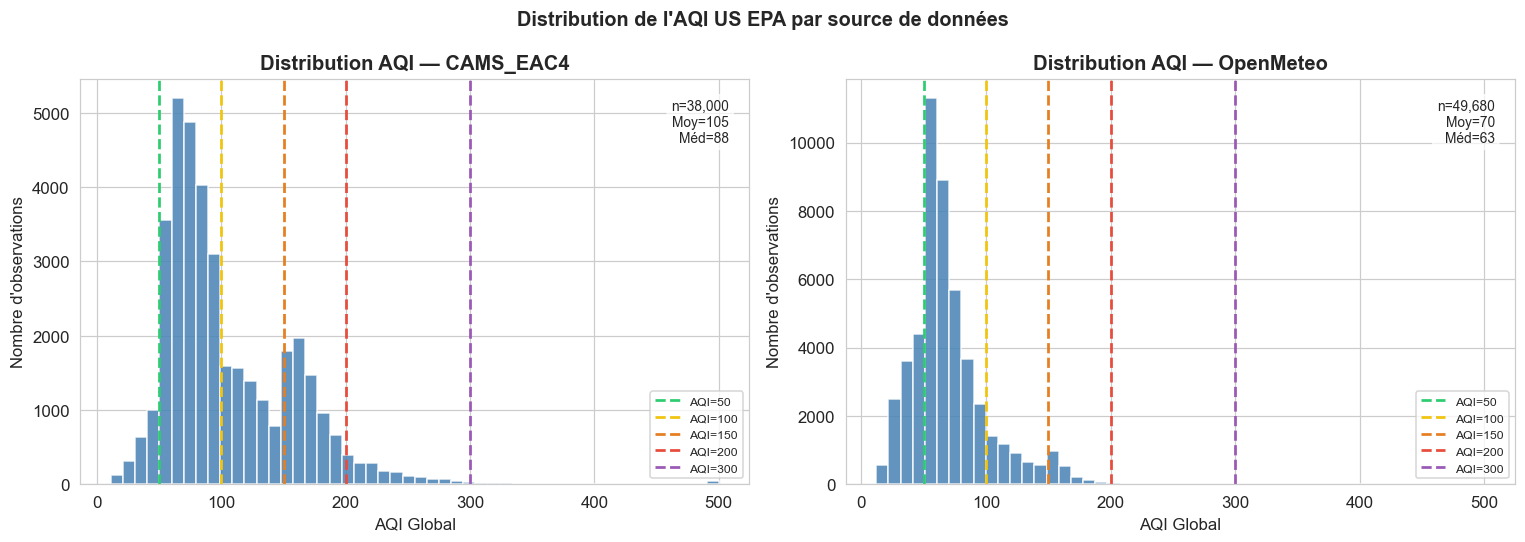

20:01:05 [INFO] [OK] Visualisation 1 sauvegardée.


In [14]:
## ── [SECTION 5 — Viz 1] Distribution de l'AQI global par source ────────────

EPA_THRESHOLDS = [50, 100, 150, 200, 300]
THRESH_LABELS  = ['Good', 'Moderate', 'USG', 'Unhealthy', 'Very\nUnhealthy']
THRESH_COLORS  = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6']

sources_present = df_final['source'].unique()
fig, axes = plt.subplots(1, len(sources_present), figsize=(14, 5), sharey=False)
if len(sources_present) == 1:
    axes = [axes]

for ax, src in zip(axes, sources_present):
    data_src = df_final.loc[df_final['source'] == src, 'aqi_global'].dropna()
    ax.hist(data_src, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    for thr, col in zip(EPA_THRESHOLDS, THRESH_COLORS):
        ax.axvline(thr, color=col, linewidth=1.8, linestyle='--', label=f'AQI={thr}')
    ax.set_title(f'Distribution AQI — {src}', fontweight='bold')
    ax.set_xlabel('AQI Global')
    ax.set_ylabel('Nombre d\'observations')
    ax.legend(fontsize=8)
    # Statistiques dans le graphe
    ax.text(0.97, 0.95,
            f'n={len(data_src):,}\nMoy={data_src.mean():.0f}\nMéd={data_src.median():.0f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

fig.suptitle('Distribution de l\'AQI US EPA par source de données', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz1_distribution_aqi.png', dpi=130, bbox_inches='tight')
plt.show()
logger.info('[OK] Visualisation 1 sauvegardée.')


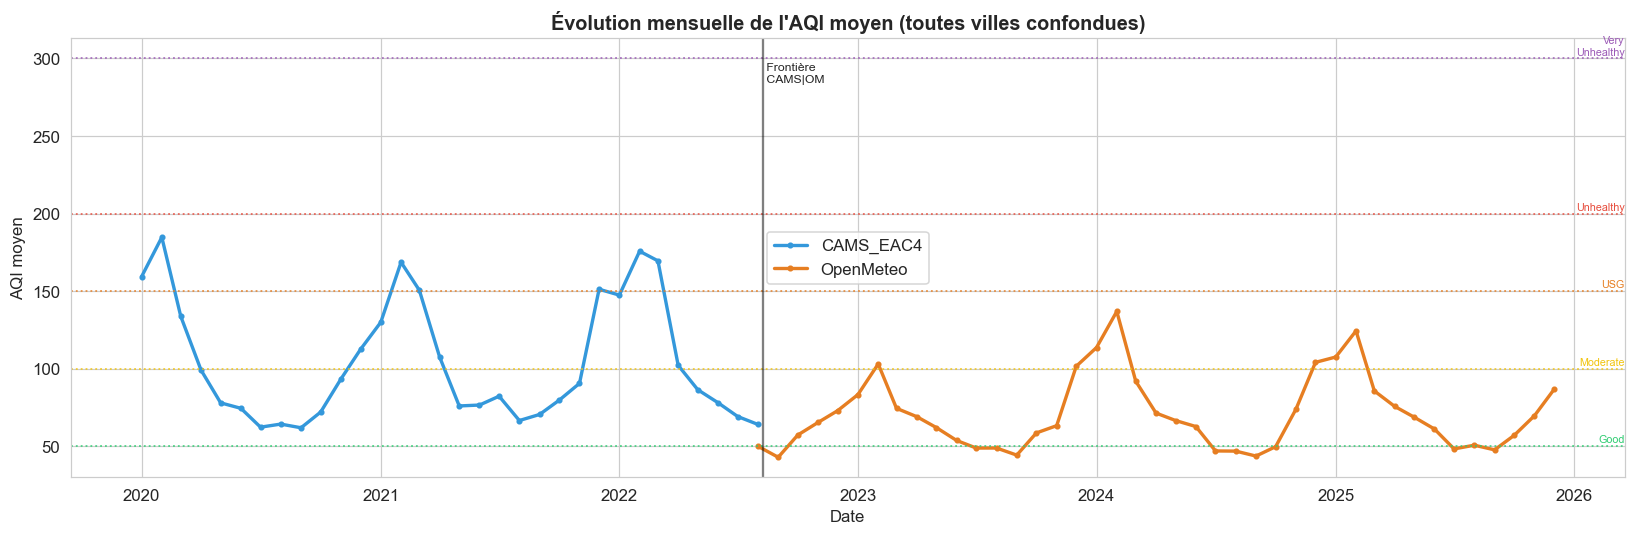

20:01:07 [INFO] [OK] Visualisation 2 sauvegardée.


In [15]:
## ── [SECTION 5 — Viz 2] Évolution mensuelle de l'AQI moyen (série temporelle)

# Calcul de la moyenne mensuelle de l'AQI sur toutes les villes
df_monthly = (
    df_final.copy()
    .assign(month=lambda d: d['date'].dt.to_period('M'))
    .groupby(['month', 'source'])['aqi_global']
    .mean()
    .reset_index()
)
df_monthly['month_dt'] = df_monthly['month'].dt.to_timestamp()

COLORS_SRC = {'CAMS_EAC4': '#3498db', 'OpenMeteo': '#e67e22'}

fig, ax = plt.subplots(figsize=(15, 5))
for src in df_monthly['source'].unique():
    sub = df_monthly[df_monthly['source'] == src].sort_values('month_dt')
    ax.plot(sub['month_dt'], sub['aqi_global'],
            color=COLORS_SRC.get(src, 'gray'), linewidth=2.2,
            label=src, marker='o', markersize=3)

for thr, col, lbl in zip(EPA_THRESHOLDS, THRESH_COLORS, THRESH_LABELS):
    ax.axhline(thr, color=col, linewidth=1.2, linestyle=':', alpha=0.8)
    ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 1, thr + 1,
            lbl, fontsize=7, color=col, ha='right', va='bottom')

ax.set_title('Évolution mensuelle de l\'AQI moyen (toutes villes confondues)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('AQI moyen')
ax.legend()
# Zone de démarcation entre les deux sources
frontier = pd.Timestamp('2022-08-08')
ax.axvline(frontier, color='black', linewidth=1.5, linestyle='-', alpha=0.5)
ax.text(frontier, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 1,
        ' Frontière\n CAMS|OM', fontsize=8, ha='left', va='top')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz2_evolution_mensuelle.png', dpi=130, bbox_inches='tight')
plt.show()
logger.info('[OK] Visualisation 2 sauvegardée.')


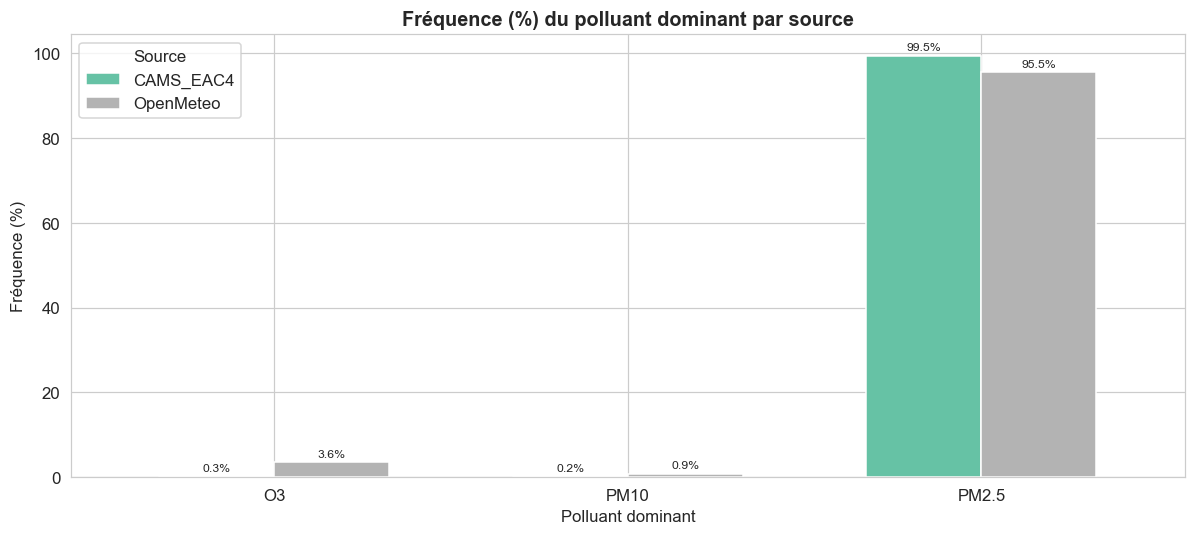

20:01:08 [INFO] [OK] Visualisation 3 sauvegardée.


In [16]:
## ── [SECTION 5 — Viz 3] Polluant dominant par source ────────────────────────

fig, ax = plt.subplots(figsize=(11, 5))

sources_list  = sorted(df_final['source'].dropna().unique())
pollutants_all = df_final['aqi_polluant_dominant'].dropna().unique()

dom_data = (
    df_final.groupby(['source', 'aqi_polluant_dominant'])
    .size()
    .reset_index(name='count')
)
# Convertir en pourcentage par source
totals = dom_data.groupby('source')['count'].transform('sum')
dom_data['pct'] = dom_data['count'] / totals * 100

dom_pivot = dom_data.pivot(index='aqi_polluant_dominant', columns='source', values='pct').fillna(0)
dom_pivot.plot(kind='bar', ax=ax, width=0.65, colormap='Set2', edgecolor='white')

ax.set_title('Fréquence (%) du polluant dominant par source', fontsize=13, fontweight='bold')
ax.set_xlabel('Polluant dominant')
ax.set_ylabel('Fréquence (%)')
ax.legend(title='Source')
ax.tick_params(axis='x', rotation=0)
# Annotations sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz3_polluant_dominant.png', dpi=130, bbox_inches='tight')
plt.show()
logger.info('[OK] Visualisation 3 sauvegardée.')


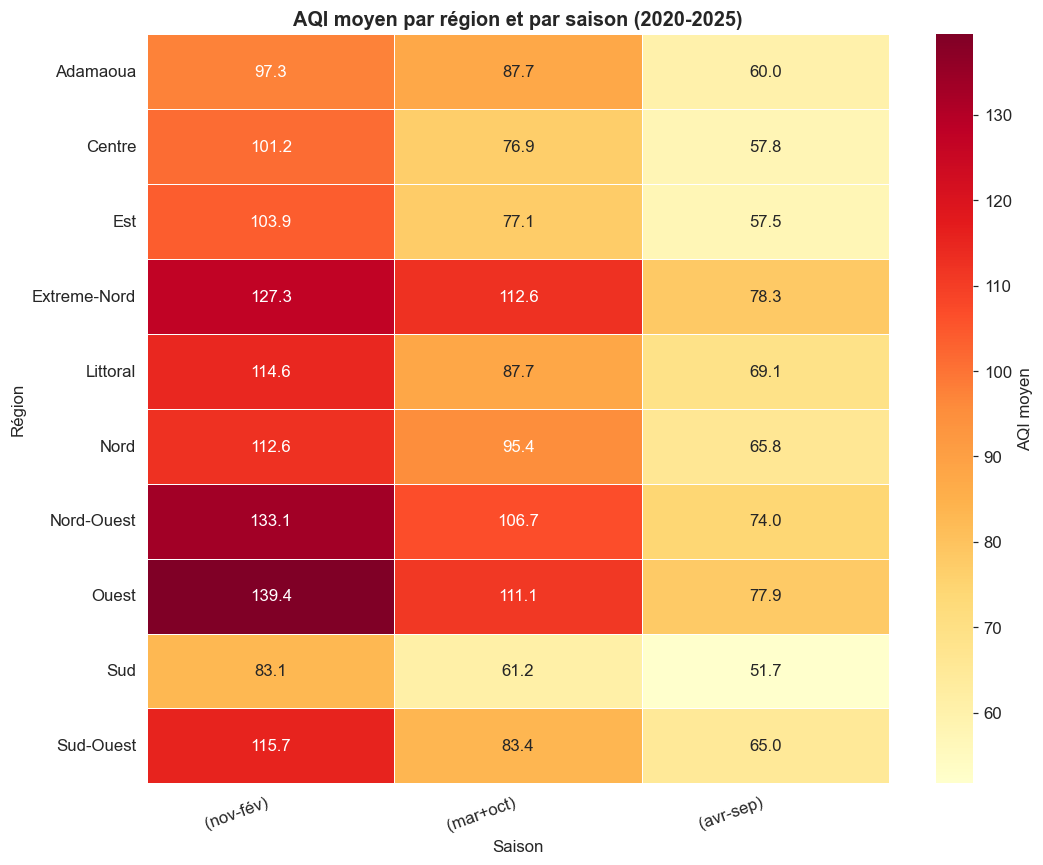

20:01:09 [INFO] [OK] Visualisation 4 sauvegardée.


In [17]:
## ── [SECTION 5 — Viz 4] AQI moyen par région et par saison ─────────────────
# Saisons camerounaises :
#   Sèche     : novembre-février  (mois 11, 12, 1, 2)
#   Transition : mars + octobre   (mois 3, 10)
#   Humide    : avril-septembre   (mois 4 à 9)

def get_saison(month):
    """Retourne la saison camerounaise selon le mois de l'année."""
    if month in [11, 12, 1, 2]:
        return '1_Sèche (nov-fév)'
    elif month in [3, 10]:
        return '2_Transition (mar+oct)'
    else:
        return '3_Humide (avr-sep)'

df_viz4 = df_final.copy()
df_viz4['saison'] = df_viz4['date'].dt.month.apply(get_saison)

heatmap_data = (
    df_viz4.groupby(['region', 'saison'])['aqi_global']
    .mean()
    .unstack('saison')
    .rename(columns=lambda c: c.split(' ', 1)[1])  # Retirer le préfixe de tri
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white', ax=ax,
    cbar_kws={'label': 'AQI moyen'}
)
ax.set_title('AQI moyen par région et par saison (2020-2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Saison')
ax.set_ylabel('Région')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz4_aqi_region_saison.png', dpi=130, bbox_inches='tight')
plt.show()
logger.info('[OK] Visualisation 4 sauvegardée.')


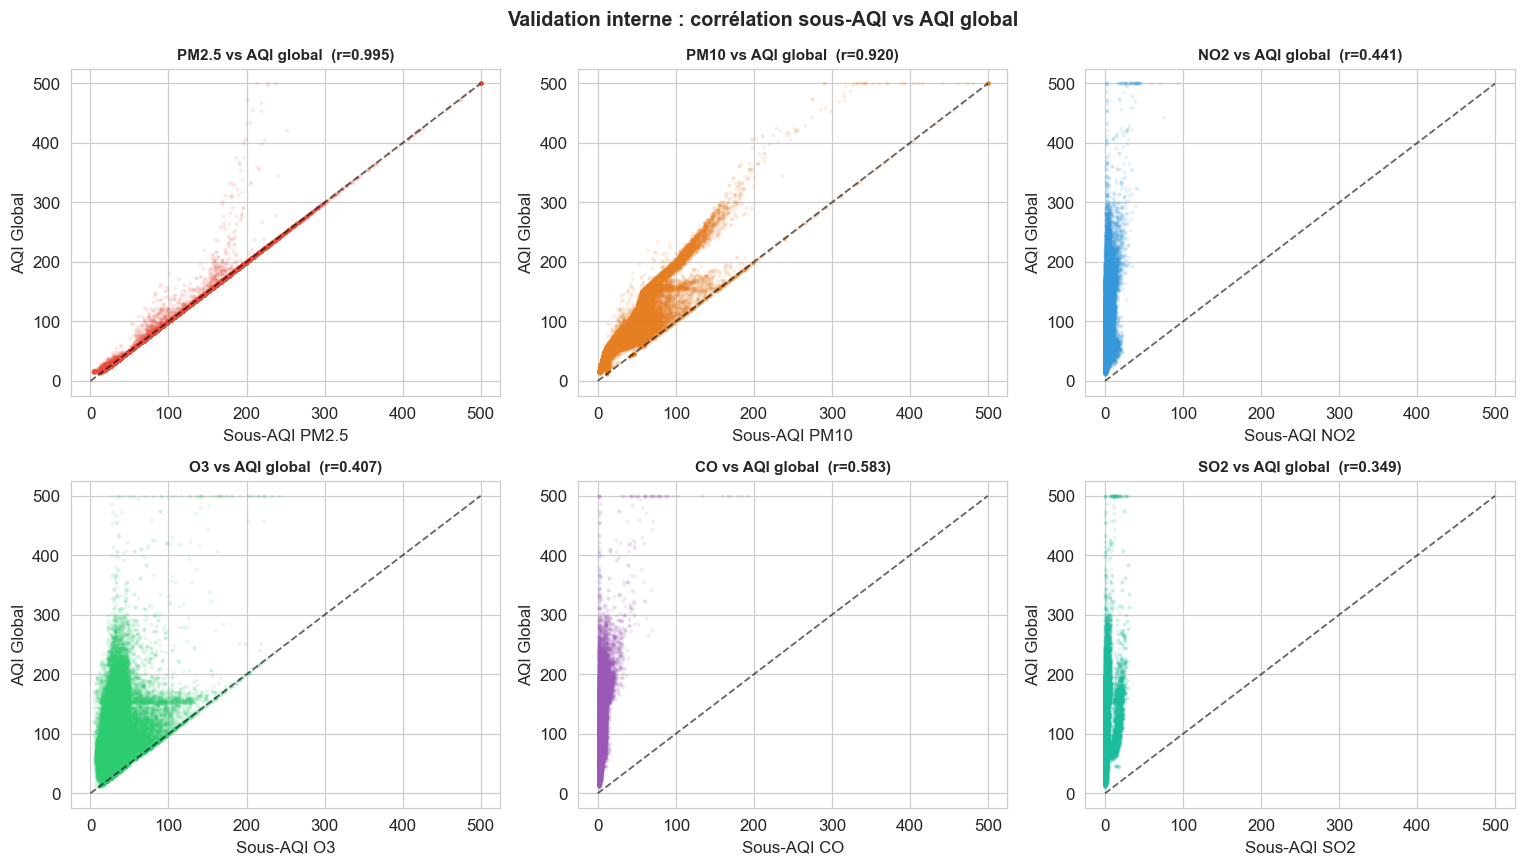

20:01:15 [INFO] [OK] Visualisation 5 — validation interne sous-AQI sauvegardée.


In [18]:
## ── [SECTION 5 — Viz 5] Note — AQI précalculé non extrait ────────────────────
# La comparaison AQI manuel vs AQI Open-Meteo précalculé n'est pas disponible
# car les variables us_aqi_* n'ont pas été extraites (choix délibéré pour
# alléger les requêtes et éviter les timeouts).
#
# Alternative : validation interne via corrélation entre les 6 sous-AQI
# et l'AQI global, pour vérifier la cohérence du calcul EPA.

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

sub_aqi_pairs = [
    ('aqi_pm2_5', 'PM2.5', '#e74c3c'),
    ('aqi_pm10',  'PM10',  '#e67e22'),
    ('aqi_no2',   'NO2',   '#3498db'),
    ('aqi_o3',    'O3',    '#2ecc71'),
    ('aqi_co',    'CO',    '#9b59b6'),
    ('aqi_so2',   'SO2',   '#1abc9c'),
]

for ax, (col, label, color) in zip(axes, sub_aqi_pairs):
    if col not in df_final.columns:
        ax.set_visible(False)
        continue
    valid = df_final[[col, 'aqi_global']].dropna()
    ax.scatter(valid[col], valid['aqi_global'],
               alpha=0.08, s=3, color=color, rasterized=True)
    # Droite y=x
    lim = max(valid[[col, 'aqi_global']].max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1.2, alpha=0.6)
    corr = valid[col].corr(valid['aqi_global'])
    ax.set_title(f'{label} vs AQI global  (r={corr:.3f})', fontsize=10, fontweight='bold')
    ax.set_xlabel(f'Sous-AQI {label}')
    ax.set_ylabel('AQI Global')

fig.suptitle('Validation interne : corrélation sous-AQI vs AQI global',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz5_validation_sous_aqi.png', dpi=130, bbox_inches='tight')
plt.show()
logger.info('[OK] Visualisation 5 — validation interne sous-AQI sauvegardée.')


## SECTION 6 — Rapport de Synthèse


In [19]:
## ── [SECTION 6] Rapport de synthèse textuel ─────────────────────────────────

print('=' * 70)
print('  RAPPORT DE SYNTHÈSE — QUALITÉ DE L\'AIR CAMEROUN 2020-2025')
print('=' * 70)

# ── Période et observations ───────────────────────────────────────────────────
print('\n── 1. COUVERTURE TEMPORELLE ──────────────────────────────────────────')
print(f'  Période globale  : {df_final["date"].min().date()} → {df_final["date"].max().date()}')
print(f'  Observations totales : {len(df_final):,}')
for src in df_final['source'].unique():
    sub = df_final[df_final['source'] == src]
    print(f'    {src:<12} : {len(sub):,} obs '
          f'({sub["date"].min().date()} → {sub["date"].max().date()})')

# ── Couverture par polluant ───────────────────────────────────────────────────
print('\n── 2. COUVERTURE PAR POLLUANT ───────────────────────────────────────')
for p, label in [('pm2_5_aqi_input','PM2.5'), ('pm10_aqi_input','PM10'),
                  ('no2_aqi_input','NO2'), ('o3_aqi_input','O3'),
                  ('co_aqi_input','CO'), ('so2_aqi_input','SO2')]:
    n_valid = df_final[p].notna().sum()
    pct     = n_valid / len(df_final) * 100
    print(f'  {label:<6} : {n_valid:>8,} obs valides ({pct:.1f}%)')

# ── Statistiques AQI global ───────────────────────────────────────────────────
print('\n── 3. STATISTIQUES AQI GLOBAL ───────────────────────────────────────')
aqi = df_final['aqi_global'].dropna()
print(f'  Moyenne  : {aqi.mean():.1f}')
print(f'  Médiane  : {aqi.median():.1f}')
print(f'  Max      : {aqi.max():.1f}')
print(f'  Écart-type : {aqi.std():.1f}')
print('\n  Distribution des catégories :')
cat_counts = df_final['aqi_categorie'].value_counts()
for cat, cnt in cat_counts.items():
    print(f'    {cat:<25} : {cnt:>8,} ({cnt/len(df_final)*100:.1f}%)')

# ── Top 5 villes AQI élevé et bas ────────────────────────────────────────────
city_aqi = df_final.groupby('city')['aqi_global'].mean().sort_values(ascending=False)
print('\n── 4. TOP 5 VILLES — AQI MOYEN LE PLUS ÉLEVÉ ───────────────────────')
for city, val in city_aqi.head(5).items():
    print(f'  {city:<15} : AQI moyen = {val:.1f}')
print('\n── 5. TOP 5 VILLES — AQI MOYEN LE PLUS BAS ─────────────────────────')
for city, val in city_aqi.tail(5).items():
    print(f'  {city:<15} : AQI moyen = {val:.1f}')

# ── Polluant dominant le plus fréquent ───────────────────────────────────────
print('\n── 6. POLLUANT DOMINANT ─────────────────────────────────────────────')
dom = df_final['aqi_polluant_dominant'].value_counts()
for poll, cnt in dom.items():
    print(f'  {poll:<8} : {cnt:>8,} jours dominants ({cnt/len(df_final)*100:.1f}%)')

# ── Limites méthodologiques ───────────────────────────────────────────────────
print('\n── 7. LIMITES MÉTHODOLOGIQUES ───────────────────────────────────────')
print('  a) CAMS EAC4 fournit 8 obs/jour (3-horaires) au lieu de 24 (horaires).')
print('     → La fenêtre glissante 8h EPA est approximée par une fenêtre 3-obs (~9h).')
print('     → Le max 1h des normes NO2 et SO2 est approximé par le max 3-horaire.')
print('  b) Les deux sources utilisent des modèles différents (EAC4 vs CAMS-NRT).')
print('     → Un léger biais de raccord peut exister autour du 8 août 2022.')
print('  c) L\'AQI US EPA 2024 pour PM2.5 utilise des seuils révisés (0-9 µg/m³ = Bon)')
print('     appliqués uniformément sur toute la période 2020-2025.')

# ── Fichiers produits ─────────────────────────────────────────────────────────
print('\n── 8. FICHIERS PRODUITS ─────────────────────────────────────────────')
output_files = [
    OUTPUT_DIR / 'openmeteo_horaire_brut.parquet',
    OUTPUT_DIR / 'sous_base_openmeteo.xlsx',
    OUTPUT_DIR / 'cams_horaire_brut.parquet',
    OUTPUT_DIR / 'sous_base_cams.xlsx',
    OUTPUT_DIR / 'air_quality_aqi_2020_2025.xlsx',
    OUTPUT_DIR / 'air_quality_aqi_2020_2025.parquet',
    OUTPUT_DIR / 'viz1_distribution_aqi.png',
    OUTPUT_DIR / 'viz2_evolution_mensuelle.png',
    OUTPUT_DIR / 'viz3_polluant_dominant.png',
    OUTPUT_DIR / 'viz4_aqi_region_saison.png',
    OUTPUT_DIR / 'viz5_validation_sous_aqi.png',
]
for fp in output_files:
    if fp.exists():
        size_kb = fp.stat().st_size / 1024
        print(f'  [OK] {fp.name:<45} ({size_kb:.0f} Ko)')
    else:
        print(f'  [--] {fp.name:<45} (non généré)')

print('\n' + '=' * 70)
print('  [OK] Notebook 03 terminé — base AQI 2020-2025 prête pour la modélisation.')
print('=' * 70)


  RAPPORT DE SYNTHÈSE — QUALITÉ DE L'AIR CAMEROUN 2020-2025

── 1. COUVERTURE TEMPORELLE ──────────────────────────────────────────
  Période globale  : 2020-01-01 → 2025-12-31
  Observations totales : 87,680
    CAMS_EAC4    : 38,000 obs (2020-01-01 → 2022-08-07)
    OpenMeteo    : 49,680 obs (2022-08-08 → 2025-12-31)

── 2. COUVERTURE PAR POLLUANT ───────────────────────────────────────
  PM2.5  :   87,680 obs valides (100.0%)
  PM10   :   87,680 obs valides (100.0%)
  NO2    :   87,680 obs valides (100.0%)
  O3     :   87,680 obs valides (100.0%)
  CO     :   87,680 obs valides (100.0%)
  SO2    :   87,680 obs valides (100.0%)

── 3. STATISTIQUES AQI GLOBAL ───────────────────────────────────────
  Moyenne  : 85.3
  Médiane  : 72.0
  Max      : 500.0
  Écart-type : 45.9

  Distribution des catégories :
    Moderate                  :   53,660 (61.2%)
    Good                      :   12,358 (14.1%)
    Unhealthy_Sensitive       :   11,161 (12.7%)
    Unhealthy                 :    8